# Ablation Study

This notebook shows an investigation into the latent space structure and the prediction head model architecture. This conducts an ablation study to understand the importance of different modeling decisions.

What this notebook does
- Loads .pt from artifacts/pretraining_checkpoints/.
- Rebuilds the same VAE architecture and tokenizer mapping used during pretraining.
- Loads tox21 train/val/test data, converts to SELFIES, and encodes with pretrained vocab.
- Color codes the latent space with tox21 labels to identify potential latent organization
- Ablation study to observe contribution of latent vector size to model performance
    - An ablation study here is to delete one of the gates and keep the others the same. There has been a great deal of work done in this direction, with the GRU architecture being one example.
- Ablation study to observe contribution of prediction head model complexity to model performance
    - As overfitting is being observed in our model, it is worthwhile to investigate whether the model architecture can be helpful to handle this issue.

##  Necessary Imports and Modules

In [ ]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import selfies as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset

try:
    import wandb
except ImportError:
    wandb = None

SEED = 42
MAX_LEN = 120

# ==== DATA SPLIT =====
VAL_FRAC = 0.10
TEST_FRAC = 0.10

# ==== TRAINING CONTROL =====
MIN_EPOCHS = 50
MAX_EPOCHS = 120
EARLY_STOPPING_PATIENCE = 12

# ==== LR SCHEDULER =====
LR_SCHEDULER_FACTOR = 0.25
LR_SCHEDULER_PATIENCE = 4

# ===== CORE MODEL =====
LATENT_DIM = 292
EMBED_DIM = 256
HIDDEN_DIM = 512
NUM_TASKS = 12
DROPOUT = 0.1

# ===== TRAINING =====
BATCH_SIZE = 128
KL_ANNEAL_EPOCHS = 10
FREE_BITS_NATS = 0.0 

PHASE1_EPOCHS = 90
PHASE1_LR = 5e-4  
PHASE1_RECON_WEIGHT = 1.0

WARMUP_EPOCHS = 15
PHASE2_EPOCHS = 80
PHASE2_PRED_WEIGHT = 1.0
PHASE2_RECON_WEIGHT = 0.0
# ========================

AUTO_RESUME = False
USE_WANDB = False 
WANDB_PROJECT = "ai-for-toxicology"
WANDB_RUN_NAME = "full-pretrain-chembl-zinc-tox21-seqconv"

# ===== CHECKPOINT SETTINGS =====
CHECKPOINT_DIR = Path("artifacts") / "end-to-end_checkpoint"
CHECKPOINT_STEM = "e2evae_full_seqconv_ce"
SAVE_EPOCH_CHECKPOINTS = False
SAVE_EPOCH_CHECKPOINTS = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)
print("torch:", torch.__version__)
print("selfies:", sf.__version__)
wandb_status = "available" if wandb is not None else "not installed"
print(f"wandb: {wandb_status} (optional)")

device: cuda
torch: 2.5.1+cu121
selfies: 2.1.1
wandb: available


## Loading the Datasets

In [ ]:
DATA_ROOT = Path("data")
CHEMBL_PATH = DATA_ROOT / "Train" / "chembl_clean.csv"
ZINC_PATH = DATA_ROOT / "Train" / "zinc250k_clean.csv"
TOX21_TRAIN_PATH = DATA_ROOT / "Train" / "tox21_train_clean.csv"
TOX21_VAL_PATH = DATA_ROOT / "Val" / "tox21_val_clean.csv"
TOX21_TEST_PATH = DATA_ROOT / "Test" / "tox21_test_clean.csv"

file_paths = [
    CHEMBL_PATH,
    ZINC_PATH,
    TOX21_TRAIN_PATH,
    TOX21_VAL_PATH,
    TOX21_TEST_PATH,
]
for p in file_paths:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")

def load_smiles(path: Path) -> list[str]:
    df = pd.read_csv(path)
    if "canonical_smiles" not in df.columns:
        raise ValueError(f"{path} does not contain canonical_smiles")
    smiles = df["canonical_smiles"].dropna().astype(str).tolist()
    return list(dict.fromkeys(smiles))

chembl_smiles = load_smiles(CHEMBL_PATH)
zinc_smiles = load_smiles(ZINC_PATH)
tox21_train_smiles = load_smiles(TOX21_TRAIN_PATH)
tox21_val_smiles = load_smiles(TOX21_VAL_PATH)
tox21_test_smiles = load_smiles(TOX21_TEST_PATH)

pretrain_smiles = list(dict.fromkeys(chembl_smiles + zinc_smiles))

TOX21_TASKS = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase",
    "NR-ER", "NR-ER-LBD", "NR-PPAR-gamma",
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53"
]

def load_tox21_labels(path):
    df = pd.read_csv(path)
    y = df[TOX21_TASKS].values.astype(np.float32)
    mask = ~np.isnan(y)
    y = np.nan_to_num(y, nan=0.0)
    return y, mask.astype(np.float32)

y_train_tox21, mask_train_tox21 = load_tox21_labels(TOX21_TRAIN_PATH)
y_val_tox21, mask_val_tox21 = load_tox21_labels(TOX21_VAL_PATH)
y_test_tox21, mask_test_tox21 = load_tox21_labels(TOX21_TEST_PATH) 

print(f"ChemBL unique SMILES:      {len(chembl_smiles):,}")
print(f"Zinc unique SMILES:        {len(zinc_smiles):,}")
print(f"Base pretraining unique:   {len(pretrain_smiles):,}")
print(f"Tox21 train unique SMILES: {len(tox21_train_smiles):,}")
print(f"Tox21 val unique SMILES:   {len(tox21_val_smiles):,}")
print(f"Tox21 test unique SMILES:  {len(tox21_test_smiles):,}") 

ChemBL unique SMILES:      23,871
Zinc unique SMILES:        249,455
Base pretraining unique:   273,321
Tox21 train unique SMILES: 6,258
Tox21 val unique SMILES:   782
Tox21 test unique SMILES:  783


In [ ]:
def split_list(data, val_frac=0.1, test_frac=0.1, seed=42):
    """
    Standard utility to split a list into Train, Val, and Test.
    """
    random.seed(seed)
    data_copy = data.copy()
    random.shuffle(data_copy)
    
    n = len(data_copy)
    n_test = int(n * test_frac)
    n_val = int(n * val_frac)
    
    test_set = data_copy[:n_test]
    val_set = data_copy[n_test : n_test + n_val]
    train_set = data_copy[n_test + n_val:]
    
    return train_set, val_set, test_set

In [ ]:
def process_aligned_data(
    smiles_list, labels=None, masks=None, max_len=MAX_LEN
):
    """
    Unified processor that keeps SELFIES, Labels, and Masks perfectly synced.
    """
    clean_selfies = []
    clean_labels = []
    clean_masks = []
    
    dropped_enc = 0
    dropped_len = 0

    for i, smi in enumerate(smiles_list):
        try:
            sf_str = sf.encoder(smi)
        except Exception:
            dropped_enc += 1
            continue
        
        if len(list(sf.split_selfies(sf_str))) > max_len:
            dropped_len += 1
            continue
            
        clean_selfies.append(sf_str)
        if labels is not None:
            clean_labels.append(labels[i])
            clean_masks.append(masks[i])

    print(f"Processed {len(smiles_list)} SMILES:"
          f" Kept {len(clean_selfies)}, "
          f"Dropped {dropped_enc} (encoding), {dropped_len} (too long)")
    
    if labels is not None:
        return (
            clean_selfies,
            np.array(clean_labels),
            np.array(clean_masks)
        )
    return clean_selfies, None, None

# Base ChemBL+Zinc split
base_train_smiles, base_val_smiles, base_test_smiles = split_list(
    pretrain_smiles, VAL_FRAC, TEST_FRAC, seed=SEED
)

# Tox21 Forbidden Set Cleaning
all_tox21_smiles = (
    set(tox21_train_smiles)
    | set(tox21_val_smiles)
    | set(tox21_test_smiles)
)
pretrain_train_smiles = [
    s for s in base_train_smiles if s not in all_tox21_smiles
]
pretrain_val_smiles = [
    s for s in base_val_smiles if s not in all_tox21_smiles
]

# Integrity check
assert set(pretrain_train_smiles).isdisjoint(all_tox21_smiles), "Overlap detected!"

# --- CONVERSION ---
print("\n>>> Converting Pre-training SMILES...")
pre_train_selfies, _, _ = process_aligned_data(pretrain_train_smiles)
pre_val_selfies, _, _ = process_aligned_data(pretrain_val_smiles)

print("\n>>> Converting Fine-tuning (Tox21) SMILES with Aligned Labels...")
ft_train_selfies, y_train_aligned, mask_train_aligned = process_aligned_data(
    tox21_train_smiles, y_train_tox21, mask_train_tox21
)
ft_val_selfies, y_val_aligned, mask_val_aligned = process_aligned_data(
    tox21_val_smiles, y_val_tox21, mask_val_tox21
)
ft_test_selfies, y_test_aligned, mask_test_aligned = process_aligned_data(
    tox21_test_smiles, y_test_tox21, mask_test_tox21
)


>>> Converting Pre-training SMILES...
Processed 218326 SMILES: Kept 218003, Dropped 0 (encoding), 323 (too long)
Processed 27293 SMILES: Kept 27257, Dropped 0 (encoding), 36 (too long)

>>> Converting Fine-tuning (Tox21) SMILES with Aligned Labels...
Processed 6258 SMILES: Kept 6237, Dropped 0 (encoding), 21 (too long)
Processed 782 SMILES: Kept 770, Dropped 0 (encoding), 12 (too long)
Processed 783 SMILES: Kept 765, Dropped 0 (encoding), 18 (too long)


### Tokenization and encoding

In [ ]:
PAD = "<PAD>"
UNK = "<UNK>"
EOS = "<EOS>"

def tokenize_selfies(s: str) -> list[str]:
    return list(sf.split_selfies(s))

all_training_selfies = pre_train_selfies + ft_train_selfies
train_tokens = [tokenize_selfies(s) for s in all_training_selfies]

vocab_tokens = sorted({tok for seq in train_tokens for tok in seq})

ALL_TOKENS = [PAD, UNK, EOS] + vocab_tokens
TOKEN_TO_IDX = {tok: i for i, tok in enumerate(ALL_TOKENS)}
IDX_TO_TOKEN = {i: tok for tok, i in TOKEN_TO_IDX.items()}

PAD_IDX = TOKEN_TO_IDX[PAD]
UNK_IDX = TOKEN_TO_IDX[UNK]
EOS_IDX = TOKEN_TO_IDX[EOS]

SEQ_LEN = MAX_LEN + 1
VOCAB_SIZE = len(ALL_TOKENS)

def encode_selfies(s: str) -> list[int]:
    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in tokenize_selfies(s)]
    ids = ids[:MAX_LEN]
    ids.append(EOS_IDX)
    return ids

def encode_list_to_numpy(selfies_list):
    """Simple encoder: takes list of SELFIES, returns padded numpy matrix."""
    out_x = np.full((len(selfies_list), SEQ_LEN), PAD_IDX, dtype=np.int64)
    for i, s in enumerate(selfies_list):
        ids = encode_selfies(s)
        out_x[i, :len(ids)] = ids
    return out_x

# ---------------------------------------------------------
# FINAL TENSOR GENERATION
# ---------------------------------------------------------
pre_train_x = encode_list_to_numpy(pre_train_selfies)
pre_val_x   = encode_list_to_numpy(pre_val_selfies)

ft_train_x = encode_list_to_numpy(ft_train_selfies)
y_train_ft, mask_train_ft = y_train_aligned, mask_train_aligned

ft_val_x   = encode_list_to_numpy(ft_val_selfies)
y_val_ft,   mask_val_ft   = y_val_aligned,   mask_val_aligned

ft_test_x  = encode_list_to_numpy(ft_test_selfies)
y_test_ft,  mask_test_ft  = y_test_aligned,  mask_test_aligned

print(
    f"Pre-train shapes:  X_train={pre_train_x.shape},"
    f"X_val={pre_val_x.shape}"
)
print(
    f"Fine-tune shapes: X_train={ft_train_x.shape},"
    f"Y_train={y_train_ft.shape}"
)
print(f"VOCAB_SIZE: {VOCAB_SIZE} | SEQ_LEN: {SEQ_LEN}")

Pre-train shapes:  X_train=(218003, 121), X_val=(27257, 121)
Fine-tune shapes: X_train=(6237, 121), Y_train=(6237, 12)
VOCAB_SIZE: 198 | SEQ_LEN: 121


# Ablation Study on Latent Dimension

## VAE Model Architecture
The following class includes the VAE Model Architecture being used in our project, where latent dimension is a variable to be adjusted. The function for loss function is included too.

In [ ]:
class VAEDataset(Dataset):
    def __init__(self, x, y=None, mask=None):
        self.x = torch.as_tensor(x).long()
        
        if y is None:
            self.y = torch.zeros((len(self.x), NUM_TASKS), dtype=torch.float32)
        else:
            self.y = torch.as_tensor(y).float()
            
        if mask is None:
            self.mask = torch.zeros(
                (len(self.x), NUM_TASKS), dtype=torch.float32
            )
        else:
            self.mask = torch.as_tensor(mask).float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.mask[idx]

class VAEWithPredictor(nn.Module):
    def __init__(self, vocab_size, seq_len, latent_dim = LATENT_DIM):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len
        self.latent_dim = latent_dim

        # ===== ENCODER (Conv1D) =====
        self.conv_1 = nn.Conv1d(vocab_size, 9, kernel_size=9)
        self.conv_2 = nn.Conv1d(9, 9, kernel_size=9)
        self.conv_3 = nn.Conv1d(9, 10, kernel_size=11)
        self.relu = nn.ReLU()

        with torch.no_grad():
            dummy = torch.zeros(1, vocab_size, seq_len)
            d = self.relu(self.conv_1(dummy))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            self.flat_features = d.flatten(1).size(1)

        self.linear_0 = nn.Linear(self.flat_features, 435)
        self.fc_mu = nn.Linear(435, self.latent_dim)
        self.fc_logvar = nn.Linear(435, self.latent_dim)

        # ===== DECODER (GRU) =====
        self.decoder_input = nn.Linear(latent_dim, 292)
        self.gru = nn.GRU(
            input_size=292, 
            hidden_size=501, 
            num_layers=3, 
            batch_first=True
        )
        self.output = nn.Linear(501, vocab_size)

        # ===== PREDICTION HEAD =====
        self.pred_head = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, NUM_TASKS)
        )

    def encode(self, x):
        x_onehot = F.one_hot(x, num_classes=self.vocab_size)
        x_onehot = x_onehot.float().transpose(1, 2).contiguous()
        
        x = self.relu(self.conv_1(x_onehot))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.flatten(1)
        x = F.selu(self.linear_0(x))
        
        return self.fc_mu(x), self.fc_logvar(x)

    def reparam(self, mu, logvar):
        eps = 1e-2 * torch.randn_like(logvar) 
        return torch.exp(0.5 * logvar) * eps + mu 
    
    def decode(self, z):
        z = F.selu(self.decoder_input(z))
        x = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(x)
        logits = self.output(out)
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        logits = self.decode(z)
        pred = self.pred_head(mu) 
        return logits, mu, logvar, pred

def compute_loss(
        logits, x, mu, logvar, pred, y, mask, beta,
        recon_weight=1.0, pred_weight=1.0, pos_weight=None
):
    recon = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        x.view(-1),
        ignore_index=PAD_IDX,
        reduction='sum' 
    )

    kl_elementwise = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl = kl_elementwise.sum() 

    if y is not None and mask.sum() > 0 and pred_weight > 0:
        bce_all = F.binary_cross_entropy_with_logits(
            pred, y, reduction='none', pos_weight=pos_weight
        )
        bce = (bce_all * mask).sum() 
    else:
        bce = torch.tensor(0.0, device=logits.device)

    batch_size = x.size(0)
    total_unnormalized = (
        (recon_weight * recon)
        + (beta * kl)
        + (pred_weight * bce)
    )
    total = total_unnormalized / batch_size

    return total, recon, kl, bce

def kl_beta(epoch):
    return min(1.0, epoch / KL_ANNEAL_EPOCHS)

## VAE Training - Loss & Function Helpers
The following functions will be used to aid training processes such as scheduling, early stopping, checkpointing, and auto-resume.

In [ ]:
def make_loader(x, y, mask, batch_size, shuffle):
    return DataLoader(
        VAEDataset(x, y, mask),
        batch_size=batch_size,
        shuffle=shuffle
    )


def init_wandb(
    *,
    run_name: str | None = None,
    epochs: int | None = None,
    start_epoch: int = 0
):
    if not USE_WANDB or wandb is None:
        return None

    return wandb.init(
        project=WANDB_PROJECT,
        name=run_name or WANDB_RUN_NAME,
        config={
            "seed": SEED,
            "latent_dim": LATENT_DIM,
            "max_epochs": epochs if epochs is not None else MAX_EPOCHS,
            "batch_size": BATCH_SIZE,
            "phase1_lr": PHASE1_LR,
            "phase2_lr": PHASE2_LR,
            "kl_anneal_epochs": KL_ANNEAL_EPOCHS,
            "vocab_size": VOCAB_SIZE,
            "seq_len": SEQ_LEN,
        },
    )


def run_epoch(
    model, loader, optimizer=None, epoch=1,
    pretrain_mode=True, pos_weight=None
):
    is_train = optimizer is not None
    if is_train:
        model.train()
    else:
        model.eval()

    metrics = {"total": 0, "recon": 0, "kl": 0, "bce": 0, "acc": 0}
    total_tokens = 0
    beta = kl_beta(epoch)

    if pretrain_mode:
        recon_w, pred_w = PHASE1_RECON_WEIGHT, 0.0
    else:
        recon_w, pred_w = PHASE2_RECON_WEIGHT, PHASE2_PRED_WEIGHT

    for x, y, mask in loader:
        x = x.to(device)
        y = y.to(device)
        mask = mask.to(device)
        if is_train: optimizer.zero_grad()
        
        logits, mu, logvar, pred = model(x)

        loss, recon_loss, kl_loss, bce_loss = compute_loss(
            logits, x, mu, logvar, pred, y, mask, beta,
            recon_weight=recon_w, pred_weight=pred_w, pos_weight=pos_weight
        )

        if is_train:
            loss.backward()
            optimizer.step()

        metrics["total"] += loss.item()
        metrics["recon"] += recon_loss.item()
        metrics["kl"] += kl_loss.item()
        metrics["bce"] += bce_loss.item()
        
        preds = logits.argmax(dim=-1)
        m = (x != PAD_IDX) 
        metrics["acc"] += ((preds == x) & m).sum().item()
        total_tokens += m.sum().item()

    num_batches = len(loader)
    num_samples = len(loader.dataset)

    return {
        "total": metrics["total"] / num_batches,
        "recon_raw": metrics["recon"] / num_samples,
        "recon_per_token": metrics["recon"] / total_tokens,
        "kl_raw": metrics["kl"] / num_samples,
        "bce_raw": metrics["bce"] / num_samples,
        "token_acc": metrics["acc"] / total_tokens
    }
 

def evaluate(
    model, x, y=None, mask=None, epoch=0, pretrain_mode=True, pos_weight=None
):
    """
    Evaluates the model on a given dataset.
    Args:
        pretrain_mode: If True, skips toxicity prediction metrics.
        pos_weight: The weight tensor for imbalanced BCE loss.
    """
    if y is None:
        y = np.zeros((len(x), NUM_TASKS), dtype=np.float32)
    if mask is None:
        mask = np.zeros((len(x), NUM_TASKS), dtype=np.float32)
        
    loader = make_loader(x, y, mask, BATCH_SIZE, shuffle=False)
    
    return run_epoch(
        model, 
        loader, 
        optimizer=None, 
        epoch=epoch, 
        pretrain_mode=pretrain_mode,
        pos_weight=pos_weight
    )

def _checkpoint_payload(
    model: nn.Module,
    history: dict,
    *,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    best_val_token_acc: float | None,
    epochs_no_improve: int,
    optimizer=None,
    scheduler=None,
    test_metrics: dict | None = None,
):
    opt_state = optimizer.state_dict() if optimizer is not None else None
    sch_state = scheduler.state_dict() if scheduler is not None else None

    return {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": opt_state,
        "scheduler_state_dict": sch_state,
        "epoch": int(epoch),
        "best_epoch": int(best_epoch) if best_epoch is not None else None,
        "best_val_total": (
            float(best_val_total) if best_val_total is not None else None,
        ),
        "best_val_token_acc": (
            float(best_val_token_acc) if best_val_token_acc is not None else None
        ),
        "epochs_no_improve": int(epochs_no_improve),
        "token_to_idx": TOKEN_TO_IDX,
        "seq_len": SEQ_LEN,
        "vocab_size": VOCAB_SIZE,
        "max_len": MAX_LEN,
        "pad_idx": PAD_IDX,
        "unk_idx": UNK_IDX,
        "eos_idx": EOS_IDX,
        "history": history,
        "test_metrics": test_metrics,
        "encoder_layout": "onehot_channels_first_seqconv",
        "decoder_output": "logits",
        "loss_name": "token_cross_entropy_plus_kl",
        "selection_metric": "val_token_acc",
    }


def _save_training_checkpoints(
    model: nn.Module,
    history: dict,
    *,
    save_dir: Path,
    checkpoint_stem: str,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    best_val_token_acc: float | None,
    epochs_no_improve: int,
    optimizer=None,
    scheduler=None,
    is_best: bool,
    save_epoch_checkpoints: bool,
):
    payload = _checkpoint_payload(
        model,
        history,
        epoch=epoch,
        best_epoch=best_epoch,
        best_val_total=best_val_total,
        best_val_token_acc=best_val_token_acc,
        epochs_no_improve=epochs_no_improve,
        optimizer=optimizer,
        scheduler=scheduler,
        test_metrics=None,
    )

    last_path = save_dir / f"{checkpoint_stem}_last.pt"
    torch.save(payload, last_path)

    if save_epoch_checkpoints:
        epoch_path = save_dir / f"{checkpoint_stem}_epoch_{epoch:03d}.pt"
        torch.save(payload, epoch_path)

    if is_best:
        best_path = save_dir / f"{checkpoint_stem}_best.pt"
        torch.save(payload, best_path)

def train_model(
    train_x: np.ndarray,
    val_x: np.ndarray,
    y_train: np.ndarray | None = None,
    mask_train: np.ndarray | None = None,
    y_val: np.ndarray | None = None,
    mask_val: np.ndarray | None = None,
    *,
    model: nn.Module | None = None,
    optimizer=None,
    scheduler=None,
    history: dict | None = None,
    start_epoch: int = 0,
    min_epochs: int = MIN_EPOCHS,
    max_epochs: int = MAX_EPOCHS,
    early_stopping_patience: int = EARLY_STOPPING_PATIENCE,
    checkpoint_dir: Path | None = None,
    checkpoint_stem: str | None = None,
    save_epoch_checkpoints: bool = SAVE_EPOCH_CHECKPOINTS,
    wandb_run_name: str | None = None,
    best_epoch: int | None = None,
    best_val_token_acc: float | None = None,
    best_val_total: float | None = None,
    epochs_no_improve: int = 0,
    pretrain_mode: bool = True,
    scheduler_mode: str = "min", 
    pos_weight: torch.Tensor | None = None,
):
    if model is None:
        model = VAEWithPredictor(VOCAB_SIZE, SEQ_LEN).to(device)
    
    if optimizer is None:
        initial_lr = PHASE1_LR if pretrain_mode else PHASE2_LR
        optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
        
    if scheduler is None:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode=scheduler_mode,
            factor=LR_SCHEDULER_FACTOR,
            patience=LR_SCHEDULER_PATIENCE,
            min_lr=1e-6,
        )

    train_loader = make_loader(train_x, y_train, mask_train, BATCH_SIZE, True)
    val_loader   = make_loader(val_x, y_val, mask_val, BATCH_SIZE, False)

    # Added raw recon trackers for diagnostics
    metrics_to_track = [
        "beta", "lr", "train_total", "val_total", 
        "train_recon_per_token", "val_recon_per_token",
        "train_recon_raw", "val_recon_raw",
        "train_kl", "val_kl", "train_token_acc", "val_token_acc",
        "train_bce", "val_bce" 
    ]
    
    if history is None:
        history = {m: [] for m in metrics_to_track}
    else:
        for key in metrics_to_track:
            history.setdefault(key, [])

    if scheduler_mode == "max":
        if best_val_token_acc is None:
            if history["val_token_acc"]:
                best_val_token_acc = float(np.max(history["val_token_acc"]))
            else:
                best_val_token_acc = float("-inf")
                
        if history["val_total"]:
            best_val_total = float(np.min(history["val_total"]))
        else:
            best_val_total = float("inf")
    else:
        if best_val_total is None:
            if history["val_total"]:
                best_val_total = float(np.min(history["val_total"]))
            else:
                best_val_total = float("inf")
            if history["val_token_acc"]:
                best_val_token_acc = float(np.max(history["val_token_acc"]))
            else:
                best_val_token_acc = float("-inf")

    if checkpoint_dir is not None:
        checkpoint_dir = Path(checkpoint_dir)
        checkpoint_dir.mkdir(parents=True, exist_ok=True)

    wandb_run = init_wandb(
        run_name=wandb_run_name,
        epochs=max_epochs,
        start_epoch=start_epoch
    )
    early_stopped = False
    last_epoch = start_epoch

    for ep in range(start_epoch + 1, max_epochs + 1):
        beta = kl_beta(ep)
        
        train_metrics = run_epoch(
            model, train_loader, optimizer=optimizer, epoch=ep, 
            pretrain_mode=pretrain_mode, pos_weight=pos_weight
        )
        val_metrics = run_epoch(
            model, val_loader, optimizer=None, epoch=ep, 
            pretrain_mode=pretrain_mode, pos_weight=pos_weight
        )

        if scheduler_mode == "max":
            scheduler.step(val_metrics["token_acc"]) 
        else:
            scheduler.step(val_metrics["total"]) 
        current_lr = float(optimizer.param_groups[0]["lr"])

        history["beta"].append(beta)
        history["lr"].append(current_lr)
        history["train_total"].append(train_metrics["total"])
        history["val_total"].append(val_metrics["total"])
        history["train_bce"].append(train_metrics["bce_raw"]) # Log raw BCE
        history["val_bce"].append(val_metrics["bce_raw"])
        history["train_token_acc"].append(train_metrics["token_acc"])
        history["val_token_acc"].append(val_metrics["token_acc"])
        history["train_recon_per_token"].append(train_metrics["recon_per_token"])
        history["val_recon_per_token"].append(val_metrics["recon_per_token"])
        history["train_recon_raw"].append(train_metrics["recon_raw"])
        history["val_recon_raw"].append(val_metrics["recon_raw"])
        history["train_kl"].append(train_metrics["kl_raw"])
        history["val_kl"].append(val_metrics["kl_raw"])
        
        if scheduler_mode == "max":
            is_best = val_metrics["token_acc"] > (best_val_token_acc + 1e-12)
        else:
            is_best = val_metrics["total"] < (best_val_total - 1e-12)

        if is_best:
            best_val_token_acc = float(val_metrics["token_acc"])
            best_val_total = float(val_metrics["total"])
            best_epoch = ep
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        # --- DIAGNOSTIC PRINTING ---
        print(f"\n[Epoch {ep:03d}] Diagnostic (Raw Magnitudes)")
        print(
            f"  TRAIN | Recon: {train_metrics['recon_raw']:10.2f} | "
            f"BCE: {train_metrics['bce_raw']:.4f} | "
            f"KL: {train_metrics['kl_raw']:.4f}"
        )
        print(
            f"  VAL   | Recon: {val_metrics['recon_raw']:10.2f} | "
            f"BCE: {val_metrics['bce_raw']:.4f} | "
            f"KL: {val_metrics['kl_raw']:.4f}"
        )
        
        status_msg = (
            f"Summary | val total={val_metrics['total']:.4f} | "
            f"val acc={val_metrics['token_acc']:.4f} | lr={current_lr:.2e}"
        )
        if is_best:
            status_msg += f" | 🔥 new best"
        print(status_msg)

        if checkpoint_dir is not None and checkpoint_stem is not None:
            _save_training_checkpoints(
                model, history, 
                save_dir=checkpoint_dir, 
                checkpoint_stem=checkpoint_stem,
                epoch=ep, 
                best_epoch=best_epoch, 
                best_val_total=best_val_total,
                best_val_token_acc=best_val_token_acc, 
                epochs_no_improve=epochs_no_improve,
                optimizer=optimizer, 
                scheduler=scheduler, 
                is_best=is_best,
                save_epoch_checkpoints=save_epoch_checkpoints
            )

        if wandb_run is not None:
            wandb_run.log({
                "epoch": ep, "beta": beta,
                "lr": current_lr,
                "train/total": train_metrics["total"],
                "val/total": val_metrics["total"],
                "train/token_acc": train_metrics["token_acc"],
                "val/token_acc": val_metrics["token_acc"],
                "train/raw_recon": train_metrics["recon_raw"],
                "val/raw_recon": val_metrics["recon_raw"],
                "train/raw_bce": train_metrics["bce_raw"],
                "val/raw_bce": val_metrics["bce_raw"],
                "best/val_total": best_val_total,
                "early_stop/no_improve": epochs_no_improve
            }, step=ep)

        last_epoch = ep
        if ep >= min_epochs and epochs_no_improve >= early_stopping_patience:
            early_stopped = True
            print(f"\n>>> Early stopping at epoch {ep}"
                  f" (patience={early_stopping_patience})"
            )
            break

    if wandb_run is not None:
        wandb_run.finish()

    return model, optimizer, scheduler, history, {
        "best_epoch": best_epoch,
        "best_val_token_acc": best_val_token_acc,
        "best_val_total": best_val_total,
        "last_epoch": last_epoch, 
        "early_stopped": early_stopped
    }

## Training Loop
The following includes the training loop, which involves pretraining on the ZINC and ChemBL dataset, as well as the subsequent fine-tuning on the Tox21 dataset. 

In [ ]:
CHECKPOINT_DIR = Path("artifacts") / "ablation_study"
CHECKPOINT_STEM = "e2evae_full_seqconv_ce"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

LATENT_DIMS = [64, 128, 292]
results_per_latent = {}

pos_counts = torch.tensor(
    (y_train_ft == 1).sum(axis=0), dtype=torch.float32
)
neg_counts = torch.tensor(
    (y_train_ft == 0).sum(axis=0), dtype=torch.float32
)
computed_pos_weights = (neg_counts / (pos_counts + 1e-6)) * 2.0 
pos_weight_tensor = computed_pos_weights.to(device)

for dim in LATENT_DIMS:
    print(f"🔥 Starting Ablation Trial: Latent Dimension = {dim}")
    history = None
    model = VAEWithPredictor(
        vocab_size=VOCAB_SIZE,
        seq_len=SEQ_LEN,
        latent_dim=dim
    ).to(device)

    print(f"\n>>> RUNNING PHASE 1: Pre-training")
    opt1 = torch.optim.Adam(model.parameters(), lr=PHASE1_LR)
    sched1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt1,
        mode="max",
        factor=LR_SCHEDULER_FACTOR,
        patience=LR_SCHEDULER_PATIENCE
    )
    model, optimizer, scheduler, history, info1 = train_model(
        pre_train_x, pre_val_x,
        model=model, optimizer=opt1, scheduler=sched1,
        history=history,
        max_epochs=PHASE1_EPOCHS,
        checkpoint_dir=CHECKPOINT_DIR,
        checkpoint_stem=f"ablation_dim_{dim}_phase1",
        pretrain_mode=True,
        scheduler_mode="max"
    )
    start_epoch = info1["last_epoch"]

    print(f"\n>>> PHASE 2: Warmup (Frozen Base, {WARMUP_EPOCHS} Epochs)")
    for name, param in model.named_parameters():
        param.requires_grad = ("pred_head" in name)
    WARMUP_LR = 1e-4
    warmup_params = filter(lambda p: p.requires_grad, model.parameters())
    opt_warmup = torch.optim.Adam(warmup_params, lr=WARMUP_LR)
    model, _, _, history, info_warmup = train_model(
        train_x=ft_train_x,
        val_x=ft_val_x,
        y_train=y_train_ft,
        mask_train=mask_train_ft,
        y_val=y_val_ft,
        mask_val=mask_val_ft,
        model=model,
        optimizer=opt_warmup,
        history=history,
        start_epoch=start_epoch,
        min_epochs=MIN_EPOCHS,
        max_epochs=start_epoch + WARMUP_EPOCHS,
        scheduler_mode="min",
        pretrain_mode=False,
        checkpoint_dir=CHECKPOINT_DIR,
        checkpoint_stem=f"ablation_dim_{dim}_warmup",
        save_epoch_checkpoints=False,
        pos_weight=pos_weight_tensor
    )
    
    print(f"\n>>> PHASE 3: Full Fine-tuning (Differential LR)")
    for param in model.parameters():
        param.requires_grad = True
    opt_groups = [
        {
            "params": [
                p for n, p in model.named_parameters() if "pred_head" in n
            ], 
            "lr": 5e-5
        },
        {
            "params": [
                p for n, p in model.named_parameters() 
                if "pred_head" not in n
            ], 
            "lr": 1e-7
        }
    ]
    opt_fine = torch.optim.AdamW(opt_groups, weight_decay=1e-2)
    sched_fine = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt_fine, mode="min", factor=0.5, patience=5
    )

    model, optimizer, scheduler, history, checkpoint_info = train_model(
        train_x=ft_train_x,
        val_x=ft_val_x,
        y_train=y_train_ft,
        mask_train=mask_train_ft,
        y_val=y_val_ft,
        mask_val=mask_val_ft,
        model=model,
        optimizer=opt_fine,
        scheduler=sched_fine,
        history=history,
        start_epoch=info_warmup["last_epoch"],
        min_epochs=MIN_EPOCHS,
        max_epochs=info_warmup["last_epoch"] + PHASE2_EPOCHS,
        best_val_total=float('inf'),
        epochs_no_improve=0,
        pretrain_mode=False,
        scheduler_mode="min",
        checkpoint_dir=CHECKPOINT_DIR,
        checkpoint_stem=f"ablation_dim_{dim}_adaptive",
        save_epoch_checkpoints=False,
        pos_weight=pos_weight_tensor
    )

    model.eval()
    def get_predictions(loader):
        probs_list, y_list, mask_list = [], [], []
        with torch.no_grad():
            for bx, by, bmask in loader:
                bx = bx.to(device)
                _, _, _, pred_logits = model(bx)
                probs = torch.sigmoid(pred_logits)
                probs_list.append(probs.cpu().numpy())
                y_list.append(by.numpy())
                mask_list.append(bmask.numpy())
        return np.vstack(probs_list), np.vstack(y_list), np.vstack(mask_list)
    
    val_loader = make_loader(
        ft_val_x, y_val_ft, mask_val_ft, BATCH_SIZE, shuffle=False
    )
    test_loader = make_loader(
        ft_test_x, y_test_ft, mask_test_ft, BATCH_SIZE, shuffle=False
    )
    
    val_probs, val_y_true, val_masks = get_predictions(val_loader)
    test_probs, test_y_true, test_masks = get_predictions(test_loader)

    
    metrics_table = []
    roc_curves = {}
    pr_curves = {}

    for task_idx, task_name in enumerate(TOX21_TASKS):
        valid_val_rows = val_masks[:, task_idx] == 1.0
        valid_test_rows = test_masks[:, task_idx] == 1.0
        
        if valid_val_rows.sum() == 0 or valid_test_rows.sum() == 0:
            continue

        y_val_task = val_y_true[valid_val_rows, task_idx]
        y_val_pred_proba = val_probs[valid_val_rows, task_idx]
        y_test_task = test_y_true[valid_test_rows, task_idx]
        y_test_pred_proba = test_probs[valid_test_rows, task_idx]

        if len(np.unique(y_test_task)) < 2 or len(np.unique(y_val_task)) < 2:
            continue

        auroc_val = roc_auc_score(y_val_task, y_val_pred_proba)
        auprc_val = average_precision_score(y_val_task, y_val_pred_proba)
        auroc_test = roc_auc_score(y_test_task, y_test_pred_proba)
        auprc_test = average_precision_score(y_test_task, y_test_pred_proba)
        metrics_table.append({
            "task": task_name,
            "auroc_val": auroc_val,
            "auprc_val": auprc_val,
            "auroc_test": auroc_test,
            "auprc_test": auprc_test,
        })

        fpr, tpr, _ = roc_curve(y_test_task, y_test_pred_proba)
        prec, rec, _ = precision_recall_curve(y_test_task, y_test_pred_proba)
        roc_curves[task_name] = (fpr, tpr)
        pr_curves[task_name] = (rec, prec)

    metrics_df = pd.DataFrame(metrics_table)

    # E. Save results to dictionary
    results_per_latent[dim] = {
        "model": {k: v.cpu() for k, v in model.state_dict().items()},
        "history": history,
        "checkpoint_info": checkpoint_info,
        "metrics_table": metrics_df,
        "roc_curves": roc_curves,
        "pr_curves": pr_curves,
    }

🔥 Starting Ablation Trial: Latent Dimension = 64

>>> RUNNING PHASE 1: Pre-training

[Epoch 001] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      87.86 | BCE: 0.0000 | KL: 0.5346
  VAL   | Recon:      87.40 | BCE: 0.0000 | KL: 0.3662
Summary | val total=87.4408 | val acc=0.3834 | lr=5.00e-04 | 🔥 new best

[Epoch 002] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      85.73 | BCE: 0.0000 | KL: 0.2637
  VAL   | Recon:      84.82 | BCE: 0.0000 | KL: 0.2373
Summary | val total=84.8699 | val acc=0.4093 | lr=5.00e-04 | 🔥 new best

[Epoch 003] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      85.23 | BCE: 0.0000 | KL: 0.2259
  VAL   | Recon:      83.70 | BCE: 0.0000 | KL: 0.2480
Summary | val total=83.7769 | val acc=0.4185 | lr=5.00e-04 | 🔥 new best

[Epoch 004] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      82.66 | BCE: 0.0000 | KL: 0.2975
  VAL   | Recon:      79.58 | BCE: 0.0000 | KL: 0.3358
Summary | val total=79.7110 | val acc=0.4255 | lr=5.00e-04 | 🔥 new best

[Epoch 005] Diagnostic 

## Evaluation on Performance
The following includes the summary of test metrics, learning curves, and AUROC and AUPRC curves.

In [92]:
# Summary Dataframe
summary_rows = []
for dim in LATENT_DIMS:
    df = results_per_latent[dim]["metrics_table"]
    for _, row in df.iterrows():
        row_dict = dict(row)
        row_dict["latent_dim"] = dim
        summary_rows.append(row_dict)

summary_df = pd.DataFrame(summary_rows)
print("\nFinal Test Metrics Summary:")
print(summary_df.groupby('latent_dim').mean(numeric_only=True))


Final Test Metrics Summary:
            auroc_val  auprc_val  auroc_test  auprc_test
latent_dim                                              
64           0.634001   0.148652    0.624431    0.148544
128          0.652913   0.164364    0.641517    0.147954
292          0.651097   0.170429    0.646684    0.146899


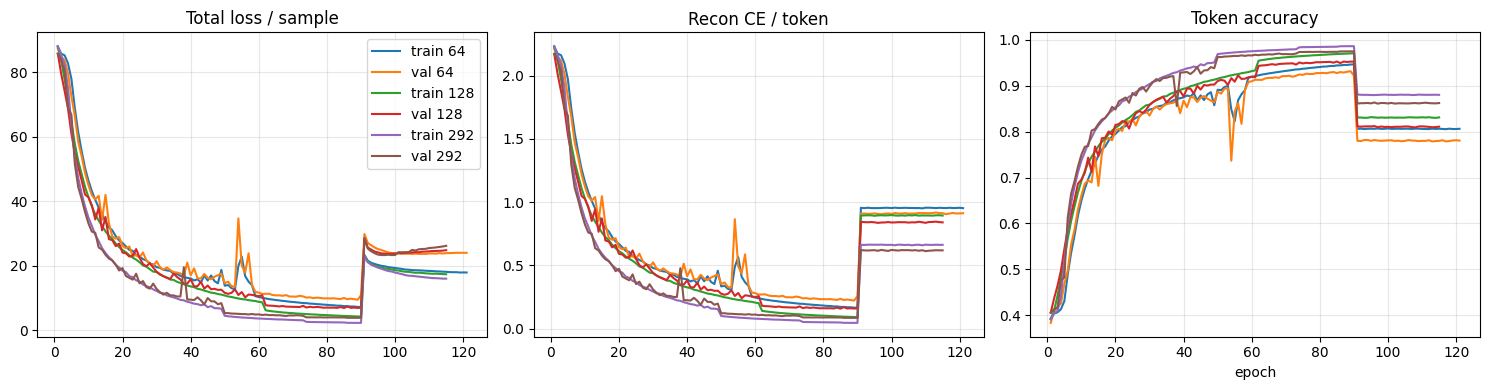

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for dim in LATENT_DIMS:
    history = results_per_latent[dim]["history"]
    epochs = np.arange(1, len(history["train_total"]) + 1)
    axes[0].plot(epochs, history["train_total"], label=f"train {dim}")
    axes[0].plot(epochs, history["val_total"], label=f"val {dim}")
    axes[1].plot(
        epochs, history["train_recon_per_token"], label=f"train {dim}"
    )
    axes[1].plot(
        epochs, history["val_recon_per_token"], label=f"val {dim}"
    )
    axes[2].plot(epochs, history["train_token_acc"], label=f"train {dim}")
    axes[2].plot(epochs, history["val_token_acc"], label=f"val {dim}")

for ax in axes:
    ax.grid(True, alpha=0.3)
axes[0].set_title("Total loss / sample")
axes[1].set_title("Recon CE / token")
axes[2].set_title("Token accuracy")
axes[2].set_xlabel("epoch")
axes[0].legend()
plt.tight_layout()
plt.show()

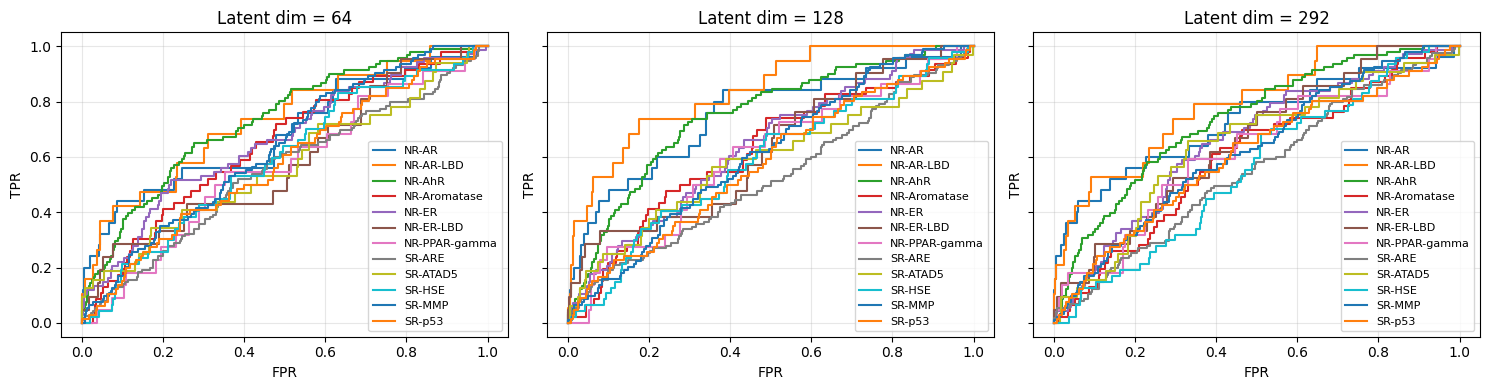

In [ ]:
# Plotting AUROC/AUPRC Curves
fig, axes = plt.subplots(
    1, len(LATENT_DIMS), figsize=(5 * len(LATENT_DIMS), 4), sharey=True
)

if len(LATENT_DIMS) == 1:
    axes = [axes]

for ax, dim in zip(axes, LATENT_DIMS):
    for task in TOX21_TASKS:
        fpr, tpr = results_per_latent[dim]["roc_curves"][task]
        ax.plot(fpr, tpr, label=task)
    ax.set_title(f"Latent dim = {dim}")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

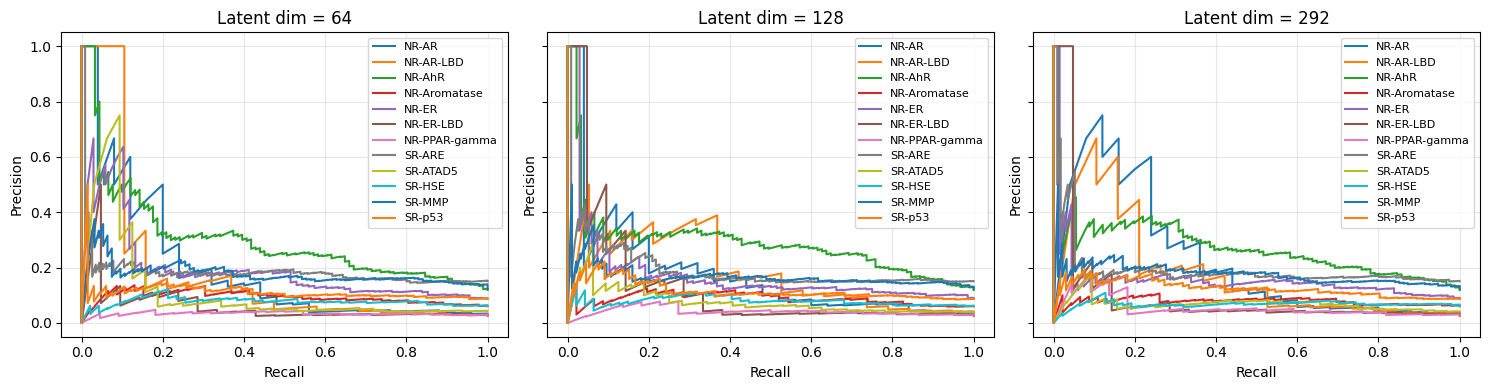

In [ ]:
fig, axes = plt.subplots(
    1, len(LATENT_DIMS), figsize=(5 * len(LATENT_DIMS), 4), sharey=True
)

if len(LATENT_DIMS) == 1:
    axes = [axes]

for ax, dim in zip(axes, LATENT_DIMS):
    for task in TOX21_TASKS:
        rec, prec = results_per_latent[dim]["pr_curves"][task]
        ax.plot(rec, prec, label=task)
    ax.set_title(f"Latent dim = {dim}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Summary Table

In [96]:
summary_rows = []
for dim in LATENT_DIMS:
    df = results_per_latent[dim]["metrics_table"]
    for _, row in df.iterrows():
        row_dict = dict(row)
        row_dict["latent_dim"] = dim
        summary_rows.append(row_dict)

summary_df = pd.DataFrame(summary_rows)
summary_df

,task,auroc_val,auprc_val,auroc_test,auprc_test,latent_dim
0,NR-AR,0.703915,0.143025,0.682216,0.200675,64
1,NR-AR-LBD,0.661315,0.094363,0.730634,0.189531,64
2,NR-AhR,0.722707,0.259515,0.729661,0.302011,64
3,NR-Aromatase,0.582739,0.084379,0.642559,0.096052,64
4,NR-ER,0.645369,0.218803,0.654275,0.197343,64
5,NR-ER-LBD,0.660773,0.122517,0.583973,0.073474,64
6,NR-PPAR-gamma,0.453694,0.062273,0.561116,0.036129,64
7,SR-ARE,0.660974,0.243287,0.547719,0.186432,64
8,SR-ATAD5,0.672464,0.088354,0.567872,0.124467,64
9,SR-HSE,0.562547,0.068288,0.588277,0.079590,64


# Ablation study on prediction head model architecture

## VAE Model Architecture
The following class includes the VAE Model Architecture being used in our project, where the complexity of the prediction head is a variable to be adjusted. The function for loss function is included too.

In [ ]:
class VAEDataset(Dataset):
    def __init__(self, x, y=None, mask=None):
        self.x = torch.as_tensor(x).long()
        
        if y is None:
            self.y = torch.zeros((len(self.x), NUM_TASKS), dtype=torch.float32)
        else:
            self.y = torch.as_tensor(y).float()
            
        if mask is None:
            self.mask = torch.zeros(
                (len(self.x), NUM_TASKS), dtype=torch.float32
            )
        else:
            self.mask = torch.as_tensor(mask).float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.mask[idx]

class VAEWithPredictor(nn.Module):
    def __init__(self, vocab_size, seq_len, latent_dim = LATENT_DIM, head_type="complex"):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len
        self.latent_dim = latent_dim
        self.head_type = head_type

        # ===== ENCODER (Conv1D) =====
        self.conv_1 = nn.Conv1d(vocab_size, 9, kernel_size=9)
        self.conv_2 = nn.Conv1d(9, 9, kernel_size=9)
        self.conv_3 = nn.Conv1d(9, 10, kernel_size=11)
        self.relu = nn.ReLU()

        with torch.no_grad():
            dummy = torch.zeros(1, vocab_size, seq_len)
            d = self.relu(self.conv_1(dummy))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            self.flat_features = d.flatten(1).size(1)

        self.linear_0 = nn.Linear(self.flat_features, 435)
        self.fc_mu = nn.Linear(435, self.latent_dim)
        self.fc_logvar = nn.Linear(435, self.latent_dim)

        # ===== DECODER (GRU) =====
        self.decoder_input = nn.Linear(latent_dim, 292)
        self.gru = nn.GRU(
            input_size=292, 
            hidden_size=501, 
            num_layers=3, 
            batch_first=True
        )
        self.output = nn.Linear(501, vocab_size)

        # ===== PREDICTION HEAD =====
        if head_type == "baseline":
            # 1. Linear Probe (Absolute Minimum Capacity)
            self.pred_head = nn.Linear(latent_dim, NUM_TASKS)

        elif head_type == "shallow":
            # 2. Constrained Bottleneck (Moderate Capacity)
            self.pred_head = nn.Sequential(
                nn.Linear(latent_dim, 128), 
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(DROPOUT),

                nn.Linear(128, NUM_TASKS)
            )

        elif head_type == "moderate":
            # 2. Constrained Bottleneck (Moderate Capacity)
            self.pred_head = nn.Sequential(
                nn.Linear(latent_dim, 256), 
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(DROPOUT),

                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(DROPOUT),
                
                nn.Linear(128, NUM_TASKS)
            )

        elif head_type == "complex":
            self.pred_head = nn.Sequential(
                nn.Linear(latent_dim, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(),
                nn.Dropout(DROPOUT),
                
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Dropout(DROPOUT),
                
                nn.Linear(256, 128),
                nn.ReLU(),
                
                nn.Linear(128, NUM_TASKS)
            )

        else:
            raise ValueError("head_type must be 'baseline', 'shallow', 'moderate', or 'complex'")

    def encode(self, x):
        x_onehot = F.one_hot(x, num_classes=self.vocab_size)
        x_onehot = x_onehot.float().transpose(1, 2).contiguous()
        
        x = self.relu(self.conv_1(x_onehot))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.flatten(1)
        x = F.selu(self.linear_0(x))
        
        return self.fc_mu(x), self.fc_logvar(x)

    def reparam(self, mu, logvar):
        eps = 1e-2 * torch.randn_like(logvar) 
        return torch.exp(0.5 * logvar) * eps + mu 
    
    def decode(self, z):
        z = F.selu(self.decoder_input(z))
        x = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(x)
        logits = self.output(out)
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        logits = self.decode(z)
        pred = self.pred_head(mu) 
        return logits, mu, logvar, pred

def compute_loss(
        logits, x, mu, logvar, pred, y, mask, beta,
        recon_weight=1.0, pred_weight=1.0, pos_weight=None
):
    recon = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        x.view(-1),
        ignore_index=PAD_IDX,
        reduction='sum' 
    )

    kl_elementwise = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl = kl_elementwise.sum() 

    if y is not None and mask.sum() > 0 and pred_weight > 0:
        bce_all = F.binary_cross_entropy_with_logits(
            pred, y, reduction='none', pos_weight=pos_weight
        )
        bce = (bce_all * mask).sum() 
    else:
        bce = torch.tensor(0.0, device=logits.device)

    batch_size = x.size(0)
    total_unnormalized = (
        (recon_weight * recon)
        + (beta * kl)
        + (pred_weight * bce)
    )
    total = total_unnormalized / batch_size

    return total, recon, kl, bce

def kl_beta(epoch):
    return min(1.0, epoch / KL_ANNEAL_EPOCHS)

In [ ]:
# Try loading the best Phase 1 model for diagnostics
model_phase1_best = VAEWithPredictor(VOCAB_SIZE, SEQ_LEN).to(device)
model_phase1_best.to(device)
phase1_best = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_phase1_best.pt"
ckpt_phase1_best = torch.load(phase1_best, map_location=device)

state_dict_phase1_best = ckpt_phase1_best["model_state_dict"]
model_phase1_best.load_state_dict(state_dict_phase1_best)
model_phase1_best.eval()

dummy_input = torch.randint(0, VOCAB_SIZE, (2, SEQ_LEN), dtype=torch.long).to(device)
logits, mean, logvar, pred = model_phase1_best(dummy_input)
print(logits.shape)  # should be [2, SEQ_LEN, VOCAB_SIZE]
print(mean.shape, logvar.shape)  # should be [2, LATENT_DIM]
print(pred.shape) # should be [2, NUM_TASKS]

torch.Size([2, 121, 198])
torch.Size([2, 292]) torch.Size([2, 292])
torch.Size([2, 12])


C:\Users\erinw\AppData\Local\Temp\ipykernel_39012\4200829897.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_phase1_best = torch.load(phase1_best, map_location=devi

## Training Loop
The following includes the training loop, which involves loading the weights of the pretrained model, and the subsequent fine-tuning on the Tox21 dataset. 

In [ ]:
head_types = ["baseline", "shallow", "moderate", "complex"]
results_per_head_types = {}

pos_counts = torch.tensor(
    (y_train_ft == 1).sum(axis=0), dtype=torch.float32
)
neg_counts = torch.tensor(
    (y_train_ft == 0).sum(axis=0), dtype=torch.float32
)
computed_pos_weights = (neg_counts / (pos_counts + 1e-6)) * 2.0 
pos_weight_tensor = computed_pos_weights.to(device)

for head_type in head_types:
    print(f"🔥 Starting Ablation Trial: Head Type = {head_type}")
    
    model = VAEWithPredictor(
        vocab_size=VOCAB_SIZE,
        seq_len=SEQ_LEN,
        head_type=head_type
    ).to(device)
    
    history = None

    print(">>> Attempting to load Phase 1 weights...")
    try:
        checkpoint = torch.load(phase1_best, map_location=device)
        if checkpoint.get("vocab_size") == VOCAB_SIZE:
            state_dict = checkpoint["model_state_dict"]
            filtered_state_dict = {
                k: v for k, v in state_dict.items()
                if not k.startswith("pred_head")
            }
            model.load_state_dict(filtered_state_dict, strict=False)
            print(">>> Phase 1 Weights loaded successfully.")
            start_epoch = checkpoint.get("epoch", PHASE1_EPOCHS)
        else:
            print(f">>> VOCAB MISMATCH: Checkpoint"
                  f"({checkpoint.get('vocab_size')}) vs Data ({VOCAB_SIZE})."
            )
    except Exception as e:
        print(f">>> Load failed. Error: {e}")

    print(f"\n>>> PHASE 2: Warmup (Frozen Base, {WARMUP_EPOCHS} Epochs)")
    for name, param in model.named_parameters():
        param.requires_grad = ("pred_head" in name)
    WARMUP_LR = 1e-4
    warmup_params = filter(lambda p: p.requires_grad, model.parameters())
    opt_warmup = torch.optim.Adam(warmup_params, lr=WARMUP_LR)
    model, _, _, history, info_warmup = train_model(
        train_x=ft_train_x,
        val_x=ft_val_x,
        y_train=y_train_ft,
        mask_train=mask_train_ft,
        y_val=y_val_ft,
        mask_val=mask_val_ft,
        model=model,
        optimizer=opt_warmup,
        history=history,
        start_epoch=start_epoch,
        min_epochs=MIN_EPOCHS,
        max_epochs=start_epoch + WARMUP_EPOCHS,
        scheduler_mode="min",
        pretrain_mode=False,
        checkpoint_dir=CHECKPOINT_DIR,
        checkpoint_stem=f"ablation_head_{head_type}_warmup",
        save_epoch_checkpoints=False,
        pos_weight=pos_weight_tensor
    )
    
    print(f"\n>>> PHASE 3: Full Fine-tuning (Differential LR)")
    for param in model.parameters():
        param.requires_grad = True
    opt_groups = [
        {
            "params": [
                p for n, p in model.named_parameters() 
                if "pred_head" in n
            ], 
            "lr": 5e-5
        },
        {
            "params": [
                p for n, p in model.named_parameters() 
                if "pred_head" not in n
            ], 
            "lr": 1e-7
        }
    ]
    opt_fine = torch.optim.AdamW(opt_groups, weight_decay=1e-2)
    sched_fine = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt_fine, mode="min", factor=0.5, patience=5
    )

    model, optimizer, scheduler, history, checkpoint_info = train_model(
        train_x=ft_train_x,
        val_x=ft_val_x,
        y_train=y_train_ft,
        mask_train=mask_train_ft,
        y_val=y_val_ft,
        mask_val=mask_val_ft,
        model=model,
        optimizer=opt_fine,
        scheduler=sched_fine,
        history=history,
        start_epoch=info_warmup["last_epoch"],
        min_epochs=MIN_EPOCHS,
        max_epochs=info_warmup["last_epoch"] + PHASE2_EPOCHS,
        best_val_total=float('inf'),
        epochs_no_improve=0,
        pretrain_mode=False,
        scheduler_mode="min",
        checkpoint_dir=CHECKPOINT_DIR,
        checkpoint_stem=f"ablation_head_{head_type}_adaptive",
        save_epoch_checkpoints=False,
        pos_weight=pos_weight_tensor
    )

    model.eval()
    def get_predictions(loader):
        probs_list, y_list, mask_list = [], [], []
        with torch.no_grad():
            for bx, by, bmask in loader:
                bx = bx.to(device)
                _, _, _, pred_logits = model(bx)
                probs = torch.sigmoid(pred_logits)
                
                probs_list.append(probs.cpu().numpy())
                y_list.append(by.numpy())
                mask_list.append(bmask.numpy())
                
        return np.vstack(probs_list), np.vstack(y_list), np.vstack(mask_list)
    
    val_loader = make_loader(
        ft_val_x, y_val_ft, mask_val_ft, BATCH_SIZE, shuffle=False
    )
    test_loader = make_loader(
        ft_test_x, y_test_ft, mask_test_ft, BATCH_SIZE, shuffle=False
    )
    val_probs, val_y_true, val_masks = get_predictions(val_loader)
    test_probs, test_y_true, test_masks = get_predictions(test_loader)

    metrics_table = []
    roc_curves = {}
    pr_curves = {}

    for task_idx, task_name in enumerate(TOX21_TASKS):
        valid_val_rows = val_masks[:, task_idx] == 1.0
        valid_test_rows = test_masks[:, task_idx] == 1.0
        if valid_val_rows.sum() == 0 or valid_test_rows.sum() == 0:
            continue

        y_val_task = val_y_true[valid_val_rows, task_idx]
        y_val_pred_proba = val_probs[valid_val_rows, task_idx]
        y_test_task = test_y_true[valid_test_rows, task_idx]
        y_test_pred_proba = test_probs[valid_test_rows, task_idx]

        if len(np.unique(y_test_task)) < 2 or len(np.unique(y_val_task)) < 2:
            continue

        auroc_val = roc_auc_score(y_val_task, y_val_pred_proba)
        auprc_val = average_precision_score(y_val_task, y_val_pred_proba)
        auroc_test = roc_auc_score(y_test_task, y_test_pred_proba)
        auprc_test = average_precision_score(y_test_task, y_test_pred_proba)

        metrics_table.append({
            "task": task_name,
            "auroc_val": auroc_val,
            "auprc_val": auprc_val,
            "auroc_test": auroc_test,
            "auprc_test": auprc_test,
        })

        fpr, tpr, _ = roc_curve(y_test_task, y_test_pred_proba)
        prec, rec, _ = precision_recall_curve(y_test_task, y_test_pred_proba)

        roc_curves[task_name] = (fpr, tpr)
        pr_curves[task_name] = (rec, prec)

    metrics_df = pd.DataFrame(metrics_table)

    results_per_head_types[head_type] = {
        "model": {k: v.cpu() for k, v in model.state_dict().items()},
        "history": history,
        "checkpoint_info": checkpoint_info,
        "metrics_table": metrics_df,
        "roc_curves": roc_curves,
        "pr_curves": pr_curves,
    }

🔥 Starting Ablation Trial: Head Type = baseline
>>> Attempting to load Phase 1 weights...
>>> Phase 1 Weights loaded successfully.

>>> PHASE 2: Warmup (Frozen Base, 15 Epochs)


C:\Users\erinw\AppData\Local\Temp\ipykernel_39012\3022697984.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(phase1_best, map_location=device)



[Epoch 091] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.45 | BCE: 23.4899 | KL: 0.5049
  VAL   | Recon:      28.22 | BCE: 28.3646 | KL: 0.7147
Summary | val total=34.1149 | val acc=0.8540 | lr=1.00e-04 | 🔥 new best

[Epoch 092] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.42 | BCE: 23.4273 | KL: 0.5049
  VAL   | Recon:      28.31 | BCE: 28.3025 | KL: 0.7147
Summary | val total=34.0140 | val acc=0.8541 | lr=1.00e-04 | 🔥 new best

[Epoch 093] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.40 | BCE: 23.3659 | KL: 0.5049
  VAL   | Recon:      28.39 | BCE: 28.2384 | KL: 0.7147
Summary | val total=33.9098 | val acc=0.8536 | lr=1.00e-04 | 🔥 new best

[Epoch 094] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.43 | BCE: 23.3051 | KL: 0.5049
  VAL   | Recon:      28.38 | BCE: 28.1776 | KL: 0.7147
Summary | val total=33.8149 | val acc=0.8528 | lr=1.00e-04 | 🔥 new best

[Epoch 095] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.42 | BCE: 23.2463 | KL: 0.5049
  V

C:\Users\erinw\AppData\Local\Temp\ipykernel_39012\3022697984.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(phase1_best, map_location=device)



[Epoch 091] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.46 | BCE: 22.9486 | KL: 0.5049
  VAL   | Recon:      28.38 | BCE: 27.1792 | KL: 0.7147
Summary | val total=31.2952 | val acc=0.8542 | lr=1.00e-04 | 🔥 new best

[Epoch 092] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.48 | BCE: 21.3049 | KL: 0.5049
  VAL   | Recon:      28.25 | BCE: 25.0757 | KL: 0.7147
Summary | val total=26.2700 | val acc=0.8539 | lr=1.00e-04 | 🔥 new best

[Epoch 093] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.42 | BCE: 20.4138 | KL: 0.5049
  VAL   | Recon:      28.36 | BCE: 24.3318 | KL: 0.7147
Summary | val total=25.1276 | val acc=0.8542 | lr=1.00e-04 | 🔥 new best

[Epoch 094] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.46 | BCE: 19.7726 | KL: 0.5049
  VAL   | Recon:      28.39 | BCE: 23.8693 | KL: 0.7147
Summary | val total=24.4976 | val acc=0.8541 | lr=1.00e-04 | 🔥 new best

[Epoch 095] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.40 | BCE: 19.4032 | KL: 0.5049
  V

C:\Users\erinw\AppData\Local\Temp\ipykernel_39012\3022697984.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(phase1_best, map_location=device)



[Epoch 091] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.49 | BCE: 22.7241 | KL: 0.5049
  VAL   | Recon:      28.15 | BCE: 27.1618 | KL: 0.7147
Summary | val total=32.4908 | val acc=0.8556 | lr=1.00e-04 | 🔥 new best

[Epoch 092] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.39 | BCE: 20.9268 | KL: 0.5049
  VAL   | Recon:      28.47 | BCE: 23.9582 | KL: 0.7147
Summary | val total=26.5822 | val acc=0.8532 | lr=1.00e-04 | 🔥 new best

[Epoch 093] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.38 | BCE: 19.8813 | KL: 0.5049
  VAL   | Recon:      28.25 | BCE: 23.3557 | KL: 0.7147
Summary | val total=25.0606 | val acc=0.8543 | lr=1.00e-04 | 🔥 new best

[Epoch 094] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.41 | BCE: 19.4516 | KL: 0.5049
  VAL   | Recon:      28.27 | BCE: 23.1569 | KL: 0.7147
Summary | val total=24.5629 | val acc=0.8552 | lr=1.00e-04 | 🔥 new best

[Epoch 095] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.39 | BCE: 19.1523 | KL: 0.5049
  V

C:\Users\erinw\AppData\Local\Temp\ipykernel_39012\3022697984.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(phase1_best, map_location=device)



[Epoch 091] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.44 | BCE: 22.3520 | KL: 0.5049
  VAL   | Recon:      28.31 | BCE: 26.4445 | KL: 0.7147
Summary | val total=31.3526 | val acc=0.8531 | lr=1.00e-04 | 🔥 new best

[Epoch 092] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.47 | BCE: 20.2238 | KL: 0.5049
  VAL   | Recon:      28.31 | BCE: 23.1648 | KL: 0.7147
Summary | val total=24.8134 | val acc=0.8538 | lr=1.00e-04 | 🔥 new best

[Epoch 093] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.42 | BCE: 19.4962 | KL: 0.5049
  VAL   | Recon:      28.28 | BCE: 22.9372 | KL: 0.7147
Summary | val total=24.1903 | val acc=0.8531 | lr=1.00e-04 | 🔥 new best

[Epoch 094] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.45 | BCE: 19.0178 | KL: 0.5049
  VAL   | Recon:      28.04 | BCE: 22.7087 | KL: 0.7147
Summary | val total=23.8437 | val acc=0.8559 | lr=1.00e-04 | 🔥 new best

[Epoch 095] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      18.42 | BCE: 18.6602 | KL: 0.5049
  V

## Evaluation on Performance
The following includes the summary of test metrics, learning curves, and AUROC and AUPRC curves.

In [101]:
# Summary Dataframe
summary_rows = []
for head_type in head_types:
    df = results_per_head_types[head_type]["metrics_table"]
    for _, row in df.iterrows():
        row_dict = dict(row)
        row_dict["head_type"] = head_type
        summary_rows.append(row_dict)

summary_df = pd.DataFrame(summary_rows)
print("\nFinal Test Metrics Summary:")
print(summary_df.groupby('head_type').mean(numeric_only=True))


Final Test Metrics Summary:
           auroc_val  auprc_val  auroc_test  auprc_test
head_type                                              
baseline    0.610734   0.120690    0.619650    0.127865
complex     0.651294   0.164225    0.642806    0.151499
moderate    0.644026   0.155896    0.652778    0.161274
shallow     0.652987   0.151642    0.647721    0.150529


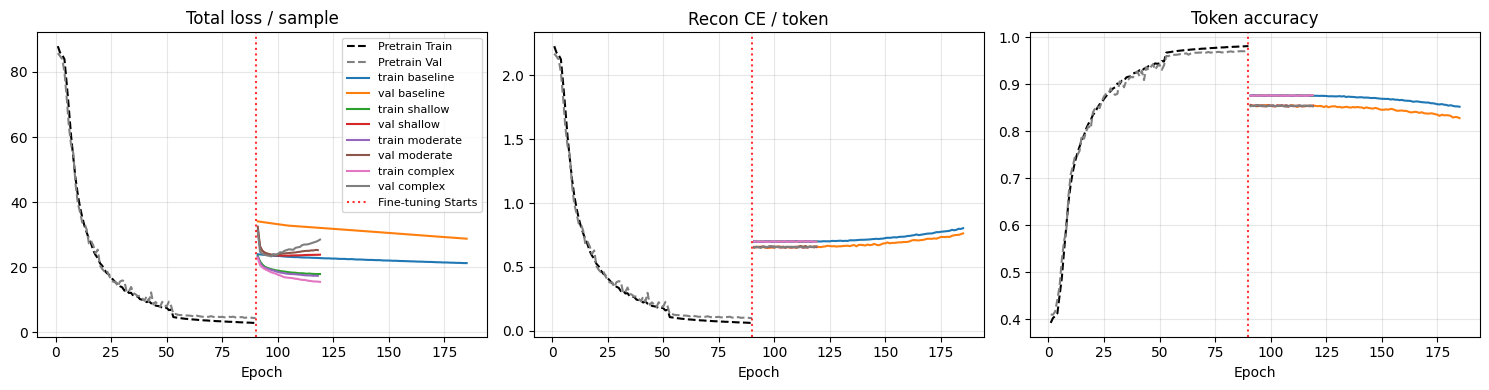

In [ ]:
# Extract the Phase 1 history from the loaded checkpoint
phase1_history = ckpt_phase1_best["history"]
phase1_epochs = np.arange(1, len(phase1_history["train_total"]) + 1)
phase1_end = phase1_epochs[-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(
    phase1_epochs, 
    phase1_history["train_total"], 
    "k--", 
    label="Pretrain Train"
)
axes[0].plot(
    phase1_epochs, 
    phase1_history["val_total"], 
    color="gray", 
    linestyle="--", 
    label="Pretrain Val"
)
axes[1].plot(phase1_epochs, phase1_history["train_recon_per_token"], "k--")
axes[1].plot(
    phase1_epochs, 
    phase1_history["val_recon_per_token"], 
    color="gray", 
    linestyle="--"
)
axes[2].plot(phase1_epochs, phase1_history["train_token_acc"], "k--")
axes[2].plot(
    phase1_epochs, 
    phase1_history["val_token_acc"], 
    color="gray", 
    linestyle="--"
)

for head_type in head_types:
    history = results_per_head_types[head_type]["history"]
    ft_epochs = np.arange(
        phase1_end + 1, phase1_end + len(history["train_total"]) + 1
    )
    axes[0].plot(
        ft_epochs, history["train_total"], label=f"train {head_type}"
    )
    axes[0].plot(
        ft_epochs, history["val_total"], label=f"val {head_type}"
    )
    axes[1].plot(
        ft_epochs, history["train_recon_per_token"], label=f"train {head_type}"
    )
    axes[1].plot(
        ft_epochs, history["val_recon_per_token"], label=f"val {head_type}"
    )
    axes[2].plot(
        ft_epochs, history["train_token_acc"], label=f"train {head_type}"
    )
    axes[2].plot(
        ft_epochs, history["val_token_acc"], label=f"val {head_type}"
    )

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Epoch")
    ax.axvline(x=phase1_end,
               color='r',
               linestyle=':',
               alpha=0.8,
               label="Fine-tuning Starts"
    )

axes[0].set_title("Total loss / sample")
axes[1].set_title("Recon CE / token")
axes[2].set_title("Token accuracy")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

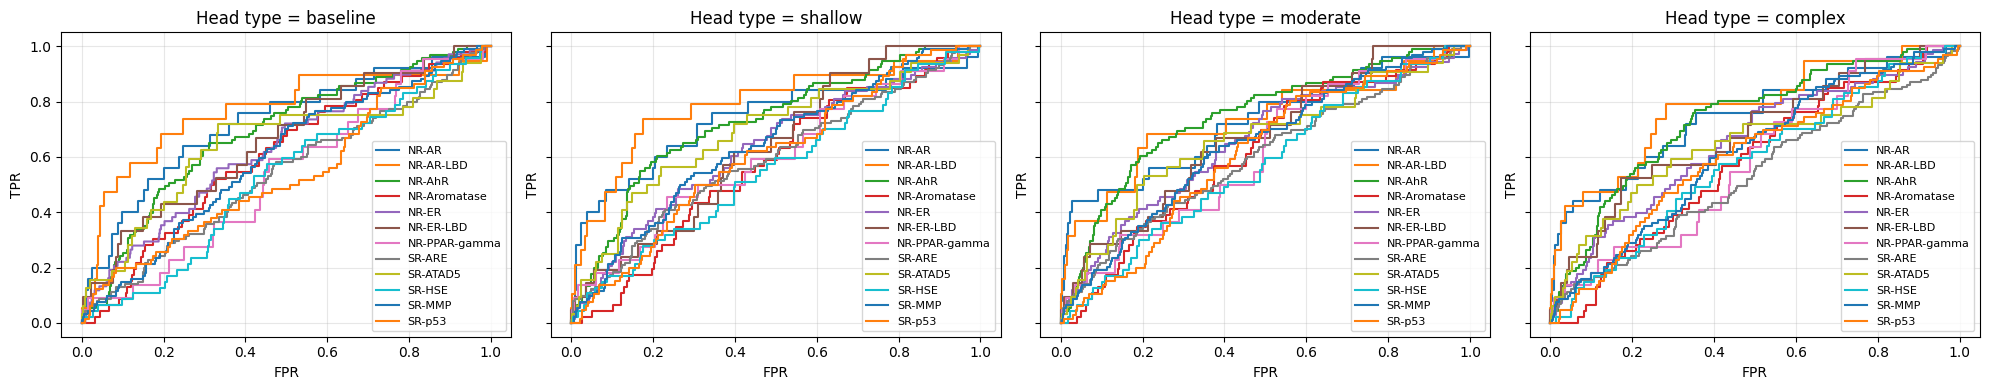

In [ ]:
fig, axes = plt.subplots(
    1, len(head_types), figsize=(5 * len(head_types), 4), sharey=True
)

if len(head_types) == 1:
    axes = [axes]

for ax, head_type in zip(axes, head_types):
    for task in TOX21_TASKS:
        fpr, tpr = results_per_head_types[head_type]["roc_curves"][task]
        ax.plot(fpr, tpr, label=task)
    ax.set_title(f"Head type = {head_type}")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

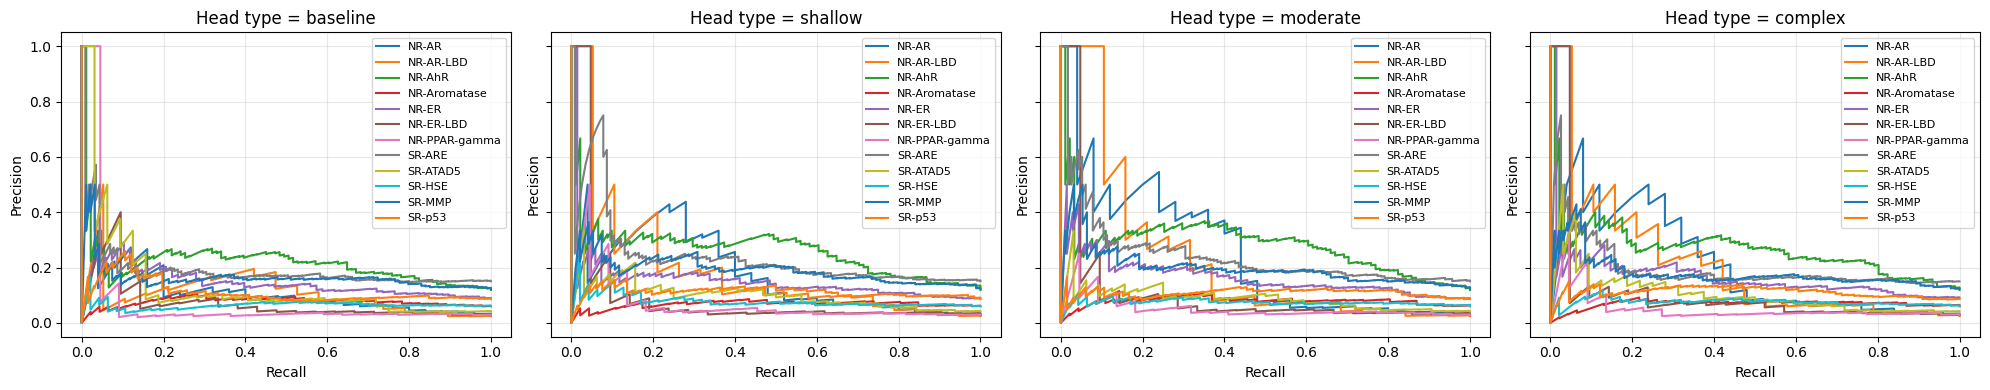

In [ ]:
fig, axes = plt.subplots(
    1, len(head_types), figsize=(5 * len(head_types), 4), sharey=True
)

if len(head_types) == 1:
    axes = [axes]

for ax, head_type in zip(axes, head_types):
    for task in TOX21_TASKS:
        rec, prec = results_per_head_types[head_type]["pr_curves"][task]
        ax.plot(rec, prec, label=task)
    ax.set_title(f"Head type = {head_type}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [105]:
summary_rows = []
for head_type in head_types:
    df = results_per_head_types[head_type]["metrics_table"]
    for _, row in df.iterrows():
        row_dict = dict(row)
        row_dict["head_type"] = head_type
        summary_rows.append(row_dict)

summary_df = pd.DataFrame(summary_rows)
summary_df

,task,auroc_val,auprc_val,auroc_test,auprc_test,head_type
0,NR-AR,0.696757,0.083761,0.723135,0.115487,baseline
1,NR-AR-LBD,0.668940,0.088571,0.764992,0.123748,baseline
2,NR-AhR,0.692954,0.215152,0.687824,0.220702,baseline
3,NR-Aromatase,0.593445,0.072371,0.602951,0.078684,baseline
4,NR-ER,0.634146,0.166184,0.630043,0.148108,baseline
5,NR-ER-LBD,0.634305,0.104052,0.658026,0.085046,baseline
6,NR-PPAR-gamma,0.550045,0.065546,0.533341,0.080632,baseline
7,SR-ARE,0.576949,0.196247,0.536736,0.191588,baseline
8,SR-ATAD5,0.613585,0.099809,0.644014,0.139406,baseline
9,SR-HSE,0.498216,0.053674,0.522166,0.067292,baseline
